## Loading Dataset

In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split


# 0. Download dataset (run once, skip if already downloaded)

# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
# !unzip -q chest-xray-pneumonia.zip -d chest_xray_data

DATA_DIR = "chest_xray_data/chest_xray"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
SUBSET_PER_CLASS = 800   # target images per class for the baseline CNN subset

## Preprocessing

In [6]:
# ------------------------------------------------------------------
# 1. Check class balance across original folders
# ------------------------------------------------------------------
print("Class counts per split:")

print(os.getcwd())
print(os.listdir())
print(os.listdir("chest_xray_data"))

for split in ["train", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        path = f"{DATA_DIR}/{split}/{cls}"
        print(f"  {split}/{cls}: {len(os.listdir(path))}")


# 2. Build a stratified subset from train

def gather_filepaths(split):
    filepaths, labels = [], []
    for label, cls in enumerate(["NORMAL", "PNEUMONIA"]):  # 0=NORMAL, 1=PNEUMONIA
        cls_dir = f"{DATA_DIR}/{split}/{cls}"
        for fname in os.listdir(cls_dir):
            filepaths.append(os.path.join(cls_dir, fname))
            labels.append(label)
    return np.array(filepaths), np.array(labels)

train_files_all, train_labels_all = gather_filepaths("train")

# Stratified subset: take up to SUBSET_PER_CLASS images per class
subset_files, subset_labels = [], []
rng = np.random.default_rng(SEED)
for label in [0, 1]:
    idx = np.where(train_labels_all == label)[0]
    n = min(SUBSET_PER_CLASS, len(idx))
    chosen = rng.choice(idx, size=n, replace=False)
    subset_files.extend(train_files_all[chosen])
    subset_labels.extend(train_labels_all[chosen])

subset_files = np.array(subset_files)
subset_labels = np.array(subset_labels)
print(f"\nSubset size: {len(subset_files)} images "
      f"({np.sum(subset_labels==0)} NORMAL, {np.sum(subset_labels==1)} PNEUMONIA)")


# 3. Stratified 80/20 train/val split of the subset

train_files, val_files, train_labels, val_labels = train_test_split(
    subset_files, subset_labels,
    test_size=0.2, stratify=subset_labels, random_state=SEED
)
print(f"Train: {len(train_files)}  Val: {len(val_files)}")


# 4. Build tf.data pipelines from file paths

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0  # normalize to [0,1]
    return img, tf.expand_dims(tf.cast(label, tf.float32), axis=-1)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def make_dataset(filepaths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_files, train_labels, training=True)
val_ds = make_dataset(val_files, val_labels, training=False)


# 5. Test set: use the FULL official test/ folder

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)
class_names = test_ds_raw.class_names
test_ds = test_ds_raw.map(lambda x, y: (x / 255.0, y)).prefetch(tf.data.AUTOTUNE)

print("\nClass names (test set):", class_names)
print("Pipeline ready: train_ds, val_ds, test_ds")

Class counts per split:
c:\Github Repos\NeuralNetworks\Project 5
['.venv', 'chest_xray_data', 'project5.ipynb']
['chest_xray']
  train/NORMAL: 1341
  train/PNEUMONIA: 3875
  test/NORMAL: 234
  test/PNEUMONIA: 390

Subset size: 1600 images (800 NORMAL, 800 PNEUMONIA)
Train: 1280  Val: 320
Found 624 files belonging to 2 classes.

Class names (test set): ['NORMAL', 'PNEUMONIA']
Pipeline ready: train_ds, val_ds, test_ds


## Baseline CNN

In [ ]:
from tensorflow.keras import models, layers, optimizers
import numpy as np

def build_baseline_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # binary output: NORMAL vs PNEUMONIA
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_model(model, train_ds, val_ds, epochs=10, run_name="baseline_run1"):
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    print(f"\n{run_name} finished after {len(history.history['loss'])} epochs")
    return history


# Run 1

tf.random.set_seed(42)
np.random.seed(42)

baseline_model = build_baseline_cnn()
baseline_model.summary()

history_baseline_run1 = train_model(baseline_model, train_ds, val_ds, epochs=10, run_name="Baseline CNN - Run 1")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


c:\Github Repos\NeuralNetworks\Project 4\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6461 - loss: 0.6296 - val_accuracy: 0.8750 - val_loss: 0.4933
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8102 - loss: 0.4629 - val_accuracy: 0.7531 - val_loss: 0.4713
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8313 - loss: 0.3801 - val_accuracy: 0.9062 - val_loss: 0.2680
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8609 - loss: 0.3362 - val_accuracy: 0.9094 - val_loss: 0.2427
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8570 - loss: 0.3407 - val_accuracy: 0.9219 - val_loss: 0.2289
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8734 - loss: 0.3131 - val_accuracy: 0.8750 - val_loss: 0.3016
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.9031 - loss: 0.2599 - val_accuracy: 0.8313 - val_loss: 0.3402
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.9117 - loss: 0.2337 - val_accuracy: 0.9375 - val_loss: 0.1723
Epo

## MobileNetV2

In [29]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(weights="imagenet",include_top=False,input_shape=(224, 224, 3))

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(.2),
    layers.Dense(1, activation="sigmoid")
])

transfer_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),loss="binary_crossentropy",metrics=["accuracy"])

transfer_model.summary()

history_transfer = train_model(transfer_model, train_ds, val_ds, epochs=10, run_name="MobileNetV2 Transfer Learning")

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 36s 723ms/step - accuracy: 0.5180 - loss: 0.8305 - val_accuracy: 0.5219 - val_loss: 0.7138
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 637ms/step - accuracy: 0.6070 - loss: 0.6595 - val_accuracy: 0.6219 - val_loss: 0.6536
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 630ms/step - accuracy: 0.6484 - loss: 0.6218 - val_accuracy: 0.7406 - val_loss: 0.5992
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 629ms/step - accuracy: 0.7008 - loss: 0.5906 - val_accuracy: 0.7781 - val_loss: 0.5547
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 629ms/step - accuracy: 0.7211 - loss: 0.5471 - val_accuracy: 0.8281 - val_loss: 0.5186
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 634ms/step - accuracy: 0.7711 - loss: 0.5117 - val_accuracy: 0.8656 - val_loss: 0.4843
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 633ms/step - accuracy: 0.8031 - loss: 0.4742 - val_accuracy: 0.8531 - val_loss: 0.4564
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 640ms/step - accuracy: 0.8102 - loss: 0.4656 - val_accu

## Performance Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 333ms/step - accuracy: 0.8862 - loss: 0.2824
Baseline Test Loss: 0.2824
Baseline Test Accuracy: 0.8862


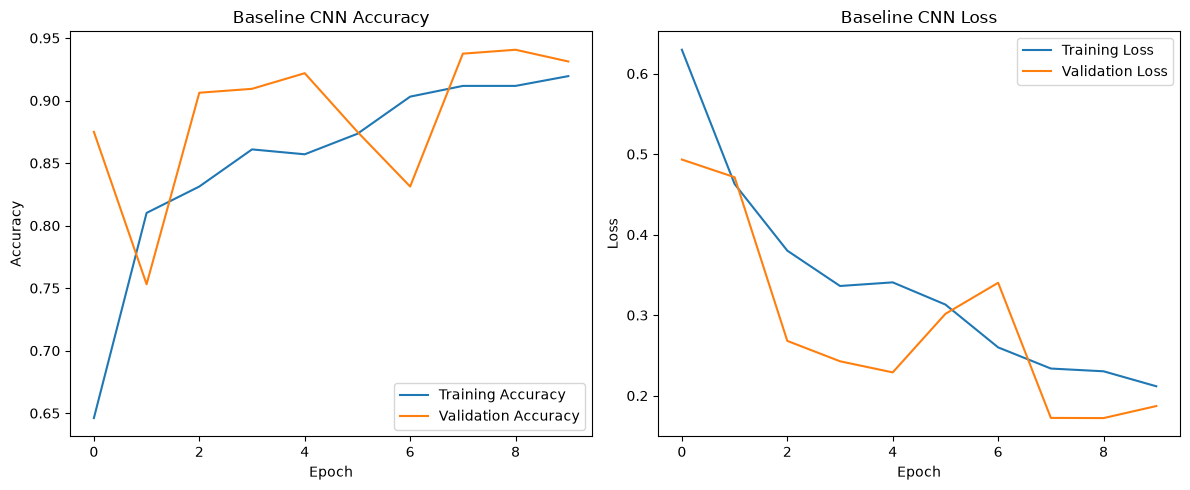

In [ ]:
# Baseline Eval

import matplotlib.pyplot as plt

test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Baseline Test Loss: {test_loss:.4f}")
print(f"Baseline Test Accuracy: {test_accuracy:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_baseline_run1.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline_run1.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline_run1.history["loss"], label="Training Loss")
plt.plot(history_baseline_run1.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()

plt.tight_layout()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 375ms/step


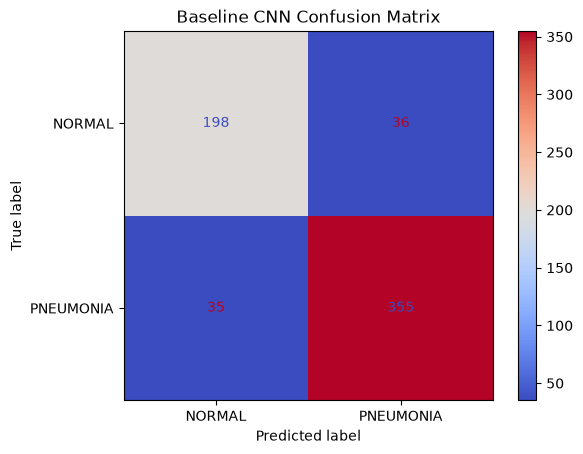

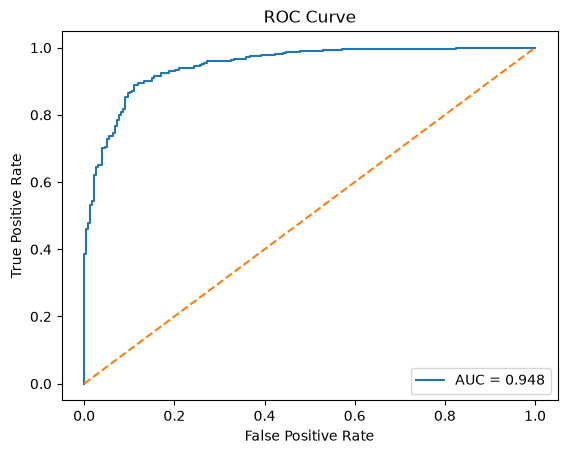

Baseline ROC AUC: 0.9478


In [ ]:
# Baseline Eval

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

y_true = np.concatenate([labels.numpy() for images, labels in test_ds])
y_prob = baseline_model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "PNEUMONIA"]).plot(cmap="coolwarm")

plt.title("Baseline CNN Confusion Matrix")
plt.show()

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"Baseline ROC AUC: {roc_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 444ms/step - accuracy: 0.7708 - loss: 0.4939
Transfer Test Loss: 0.4939
Transfer Test Accuracy: 0.7708


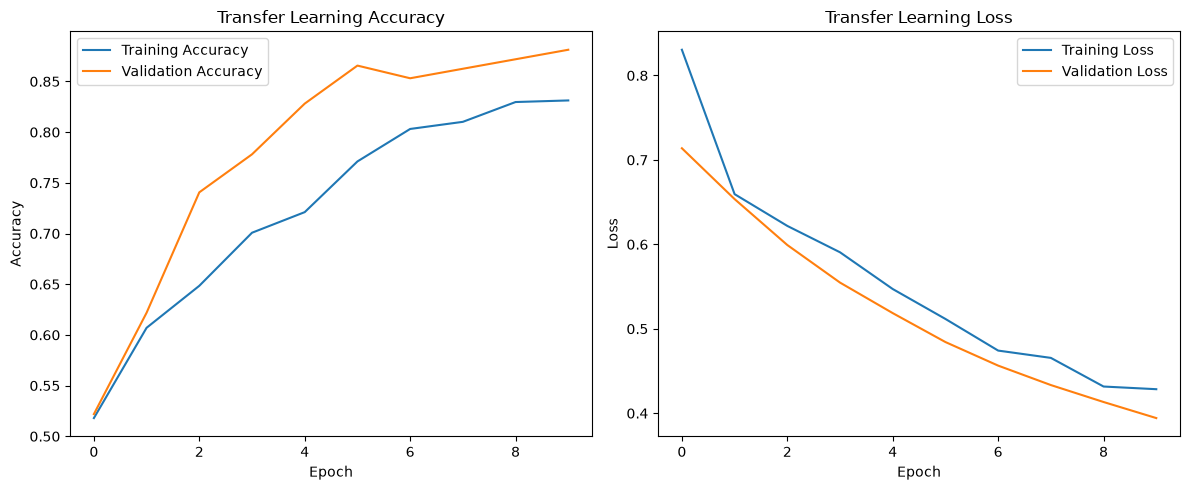

In [30]:
# Transfer Learning Eval

import matplotlib.pyplot as plt

transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_ds)

print(f"Transfer Test Loss: {transfer_test_loss:.4f}")
print(f"Transfer Test Accuracy: {transfer_test_accuracy:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_transfer.history["accuracy"], label="Training Accuracy")
plt.plot(history_transfer.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history["loss"], label="Training Loss")
plt.plot(history_transfer.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()

plt.tight_layout()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 523ms/step


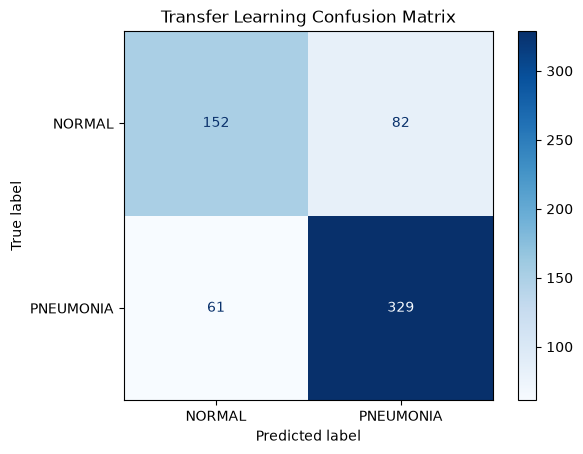

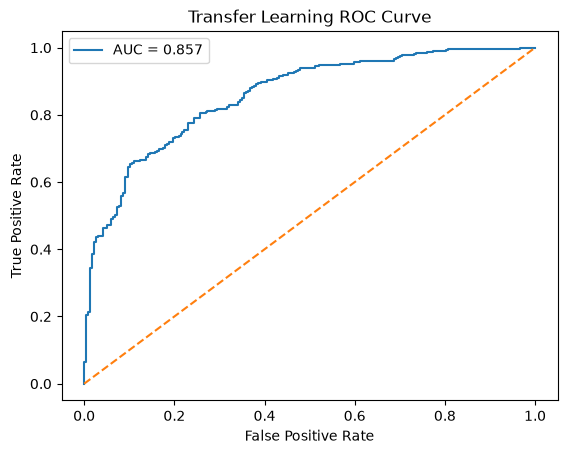

Transfer ROC AUC: 0.8574


In [31]:
# Transfer Learning Eval

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

y_true_transfer = np.concatenate([labels.numpy() for images, labels in test_ds])
y_prob_transfer = transfer_model.predict(test_ds).ravel()
y_pred_transfer = (y_prob_transfer >= 0.5).astype(int)

cm_transfer = confusion_matrix(y_true_transfer, y_pred_transfer)

ConfusionMatrixDisplay(confusion_matrix=cm_transfer, display_labels=["NORMAL", "PNEUMONIA"]).plot(cmap="Blues")

plt.title("Transfer Learning Confusion Matrix")
plt.show()

fpr_transfer, tpr_transfer, thresholds_transfer = roc_curve(y_true_transfer,y_prob_transfer)

roc_auc_transfer = auc(fpr_transfer,tpr_transfer)

plt.plot(fpr_transfer,tpr_transfer,label=f"AUC = {roc_auc_transfer:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Transfer Learning ROC Curve")
plt.legend()
plt.show()

print(f"Transfer ROC AUC: {roc_auc_transfer:.4f}")

##### Unfortunately, the transfer learning model is performing worse than the baseline. This is shown by the lower accuracy, higher loss rate, a worse ROC curve, and a worse confusion matrix. As of writing this, we have not figured out how to make it work better.

## Next Section